In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from logistic_regression import LogisticRegression

In [2]:
from sklearn.datasets import load_breast_cancer

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

clf = LogisticRegression(lr=0.1, n_iterations=500)
clf.fit(X_train_s, y_train)

preds = clf.predict(X_test_s)
print(f"Test accuracy: {accuracy_score(y_test, preds):.3f}")

Test accuracy: 0.979


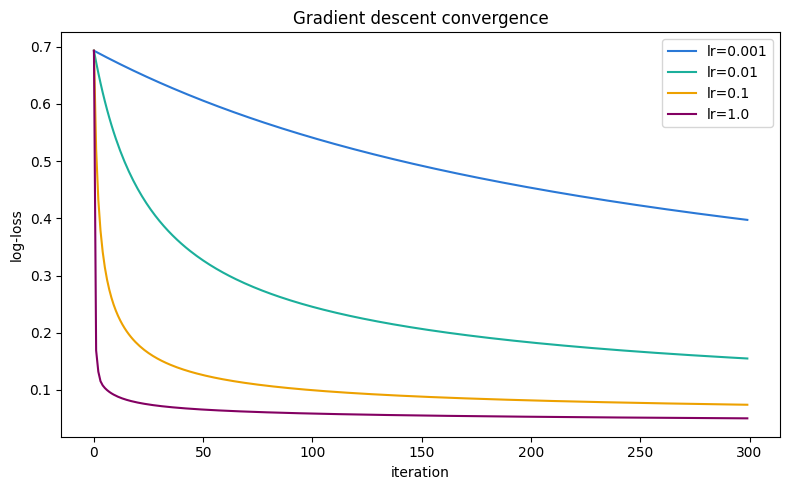

In [7]:
def train_with_loss_curve(X, y, lr, n_iterations):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0.0
    losses = []
    eps = 1e-12
    for _ in range(n_iterations):
        z = X @ weights + bias
        p = 1 / (1 + np.exp(-z))
        loss = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
        losses.append(loss)
        error = p - y
        weights -= lr * (X.T @ error) / n_samples
        bias -= lr * np.sum(error) / n_samples
    return losses

LR_CURVE_COLORS = ["#2a78d6", "#1baf9b", "#eda100", "#830062"]
learning_rates = [0.001, 0.01, 0.1, 1.0]

fig, ax = plt.subplots(figsize=(8, 5))
for color, lr_val in zip(LR_CURVE_COLORS, learning_rates):
    losses = train_with_loss_curve(X_train_s, y_train.astype(np.float64), lr_val, 300)
    ax.plot(losses, color=color, label=f"lr={lr_val}")

ax.set_xlabel("iteration")
ax.set_ylabel("log-loss")
ax.set_title("Gradient descent convergence")
ax.legend()

plt.tight_layout()
plt.show()

Test accuracy: 1.000


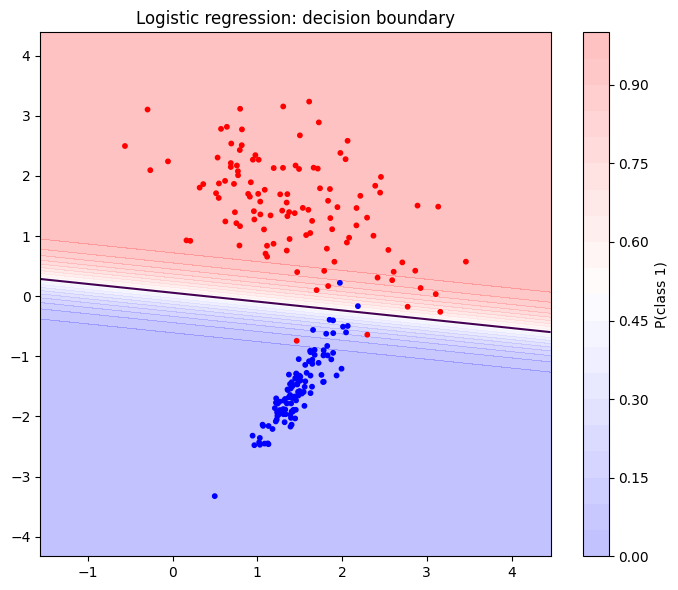

In [12]:
from sklearn.datasets import make_classification

X2, y2 = make_classification(
    n_samples=300, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.5, random_state=42
)
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.25, random_state=42, stratify=y2
)

clf2d = LogisticRegression(lr=0.5, n_iterations=500)
clf2d.fit(X2_train, y2_train)
print(f"Test accuracy: {accuracy_score(y2_test, clf2d.predict(X2_test)):.3f}")


CLASS_COLORS = ["b", "r"]
DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "colormap", ["b", "w", "r"]
)

pad = 1.0
x_min, x_max = X2[:, 0].min() - pad, X2[:, 0].max() + pad
y_min, y_max = X2[:, 1].min() - pad, X2[:, 1].max() + pad
xv, yv = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = clf2d.predict_proba(np.c_[xv.ravel(), yv.ravel()]).reshape(xv.shape)

fig, ax = plt.subplots(figsize=(7, 6))
cf = ax.contourf(xv, yv, Z, levels=20, cmap=DIVERGING_CMAP, alpha=0.25, vmin=0, vmax=1)
ax.contour(xv, yv, Z, levels=[0.5], zorder=2)
ax.scatter(
    X2_train[:, 0], X2_train[:, 1],
    c=[CLASS_COLORS[c] for c in y2_train],
    s=10, zorder=3,
)

ax.set_title("Logistic regression: decision boundary")
fig.colorbar(cf, ax=ax, label="P(class 1)")

plt.tight_layout()
plt.show()